# 練習使用 Naive Bayes 技術，收集各國股市前日收盤漲跌情形進行台灣股市漲跌的預測

### 因為時間區域不同，各國股市收盤時間是不一樣的，但會有連動的影響，我們可以根據過去歷史紀錄，分析國際股市的連動關聯性並建構談灣股市當日的漲跌狀態，換句話說，可以使用其他國家前一日或是當日正在進行的股市漲跌情形來預測台灣股市當日的股票漲跌的趨勢。此實驗藉由使用  Yahoo! Finance's API 來下載各國股市數據。

## yfinance offers a threaded and Pythonic way to download market data from Yahoo!Ⓡ finance.
## yfinance is not affiliated, endorsed, or vetted by Yahoo, Inc. It's an open-source tool that uses Yahoo's publicly available APIs, and is intended for research and educational purposes.
## https://pypi.org/project/yfinance/

## Naive Bayes classifier Model
<img src="NB_formula.jpg" width="600">

## Naive Bayes classifier for multivariate Bernoulli models.


### 1. GaussianNB -- Gaussian Naive Bayes (GaussianNB).
#### Can perform online updates to model parameters via partial_fit. For details on algorithm used to update feature means and variance online, see Stanford CS tech report STAN-CS-79-773 by Chan, Golub, and LeVeque:
#### http://i.stanford.edu/pub/cstr/reports/cs/tr/79/773/CS-TR-79-773.pdf
#### 高斯分類器主要用於特徵為連續變數時，比方說特徵長度為幾公分、重量為幾公斤等等。在這個模型下，假設特徵資料服從常態分配。

### 2. MultinomialNB -- Naive Bayes classifier for multinomial models. 
#### The multinomial Naive Bayes classifier is suitable for classification with discrete features (e.g., word counts for text classification). The multinomial distribution normally requires integer feature counts. However, in practice, fractional counts such as tf-idf may also work.
#### 多項式貝氏分類器主要用在離散變數，比方說次數、類別等等。而在個模型中，會多一個 alpha 參數，也就是平滑化的處理。

### 3. BernoulliNB -- Naive Bayes classifier for multivariate Bernoulli models.
#### Like MultinomialNB, this classifier is suitable for discrete data. The difference is that while MultinomialNB works with occurrence counts, BernoulliNB is designed for binary/boolean features.
#### 伯努力貝氏分類器主要適用於二元的特徵，比方說特徵是否出現、特徵大小、特徵長短等等這種二元的分類。

### 4. CategoricalNB -- Naive Bayes classifier for categorical features.
#### The categorical Naive Bayes classifier is suitable for classification with discrete features that are categorically distributed (also called a generalized Bernoulli distribution, multinoulli distribution) ). The categories of each feature are drawn from a categorical distribution.


### 5. ComplementNB -- The Complement Naive Bayes classifier described in Rennie et al. (2003).
#### The Complement Naive Bayes classifier was designed to correct the “severe assumptions” made by the standard Multinomial Naive Bayes classifier. It is particularly suited for imbalanced data sets.

In [1]:
pip install yfinance --upgrade --no-cache-dir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 1.0 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytz  # 使用 pytz 處理 Python的時區問題
import seaborn as sn
import yfinance as yf
import time
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB

# direct timezone cache to use local location
yf.set_tz_cache_location('cache/')

## yfinance: Download market data from Yahoo! Finance's API

yfinance is not affiliated, endorsed, or vetted by Yahoo, Inc. It's an open-source tool that uses Yahoo's publicly available APIs, and is intended for research and educational purposes.

https://github.com/ranaroussi/yfinance

參考連結 Yahoo! Finance Global Indices：https://finance.yahoo.com/world-indices  
參考連結 Apple Inc. (AAPL) https://finance.yahoo.com/quote/AAPL?p=AAPL&.tsrc=fin-srch

[*********************100%***********************]  1 of 1 completed


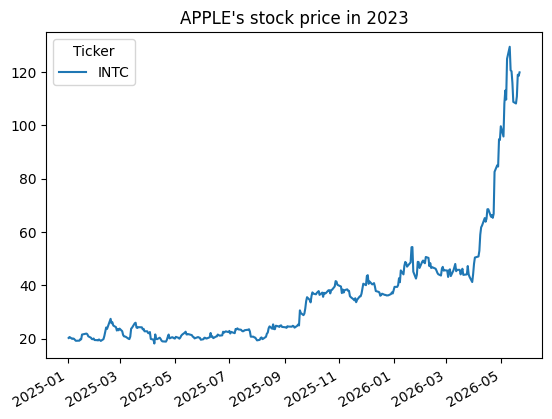

Price,Close,High,Low,Open,Volume
Ticker,INTC,INTC,INTC,INTC,INTC
2026-05-18,108.169998,115.540001,103.849998,113.470001,145764000
2026-05-19,110.800003,113.070000,102.400002,106.980003,150234900
2026-05-20,118.959999,121.940002,114.800003,116.220001,165086900
2026-05-21,118.500000,119.410004,113.169998,116.580002,102452500
2026-05-22,119.839996,122.779999,118.089996,120.339996,82206800


In [ ]:
# Example of downloading APPle Inc. historical stock data
# Using "download"  method -->  yf.download(ticker, start = start, end=end, progress=Fasle)
aapl_df = yf.download('INTC', '2025-01-01', '2025-12-31')

# Plot the close price of the AAPL
aapl_df['Close'].plot(title="APPLE's stock price in 2023")
plt.show()
aapl_df.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
2026-04-23,255.080002,258.790009,253.070007,255.389999,39091400
2026-04-24,263.989990,264.500000,257.690002,259.980011,53777400
2026-04-27,261.119995,264.149994,260.339996,263.459991,44906800
2026-04-28,259.700012,261.029999,256.630005,258.390015,42204400
2026-04-29,263.040009,265.910004,257.700012,257.989990,72367900


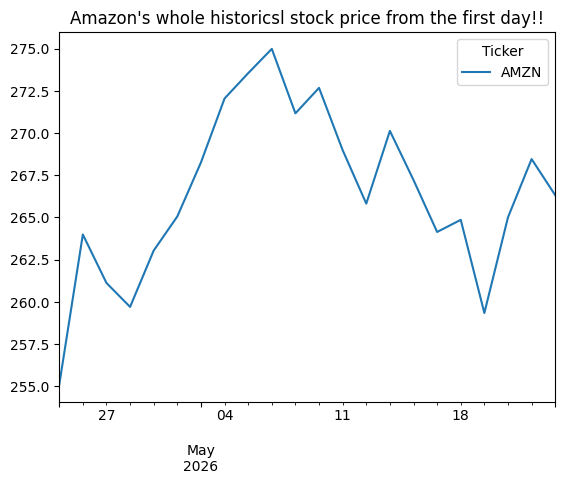

In [7]:
# If not specifically assigned the starting and ending dates, it will download whole dataset of the ticker, form 1980-12-12 to today!)
amzn_df = yf.download('AMZN')
plt.show()
amzn_df['Close'].plot(title="Amazon's whole historicsl stock price from the first day!!")
amzn_df.head()
# For Amazon company -->  from 1997/05/15 - 2026/05/20

In [8]:
# Want data for the most recent trading days
recent_data = yf.download("AAPL", period="5d")
print(recent_data)

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
2026-05-18  297.839996  300.660004  294.910004  300.239990  34483000
2026-05-19  298.970001  300.510010  296.350006  296.970001  42243600
2026-05-20  302.250000  302.799988  298.079987  298.179993  38229800
2026-05-21  304.989990  305.540009  300.399994  301.059998  42965100
2026-05-22  308.820007  311.399994  305.839996  306.119995  43627900


In [9]:
# Fetching Data for Multiple Tickers
# Retrieve data for multiple stocks simueltaneously
multi_data = yf.download(["AAPL", "MSFT"], start="2025-01-01", end="2025-12-31")
print(multi_data)

[*********************100%***********************]  2 of 2 completed

Price            Close                    High                     Low  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2025-01-02  242.301926  413.672607  247.518596  421.074816  240.284814   
2025-01-03  241.815018  418.386719  242.629804  419.058739  240.354349   
2025-01-06  243.444611  422.834015  245.759820  429.228164  241.656035   
2025-01-07  240.672333  417.418182  243.991125  425.601107  239.817792   
2025-01-08  241.159225  419.582489  242.162823  421.964238  238.526055   
...                ...         ...         ...         ...         ...   
2025-12-23  271.854919  484.691559  271.994674  485.667195  269.060124   
2025-12-24  273.302216  485.856323  274.919206  486.991284  271.695216   
2025-12-26  272.892975  485.547729  274.859323  485.955915  272.353968   
2025-12-29  273.252350  484.940430  273.851213  486.184888  271.844961   
2025-12-30  272.573578  485.318756  27

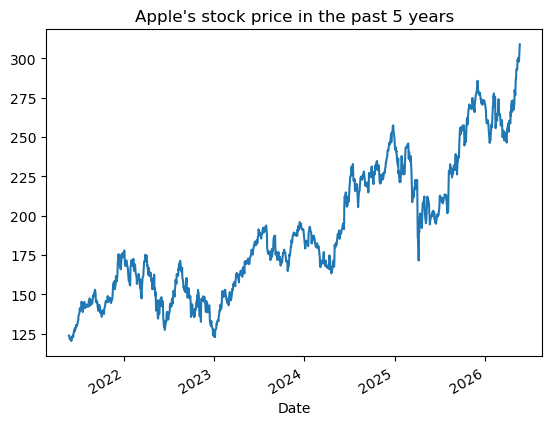

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-12-23,271.854919,271.994674,269.060124,270.337749,29642000
2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600
2025-12-26,272.892975,274.859323,272.353968,273.651575,21521800
2025-12-29,273.252350,273.851213,271.844961,272.184327,23715200
2025-12-30,272.573578,273.571723,271.775074,272.304090,22139600


In [10]:
# Example for ploting Apple stock trend in the past 5 years
# Using "Ticker" module to assign one specific ticker , and use "hostory()"" method to access ticker data in a more Pythonic way.
tickerData = yf.Ticker('AAPL')
aapl_df_5y = tickerData.history(period="5y")
aapl_df_5y['Close'].plot(title="Apple's stock price in the past 5 years")
plt.show()
aapl_df.tail()

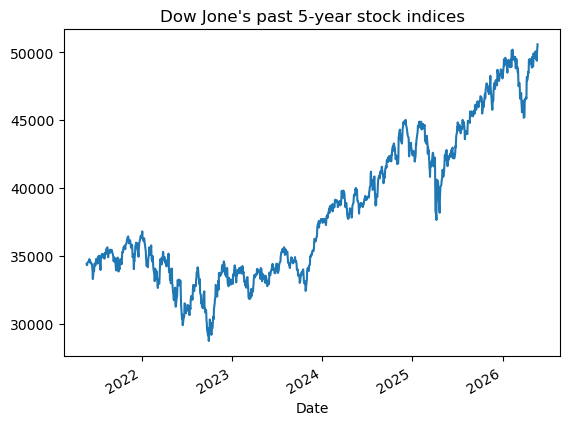

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-18 00:00:00-04:00,49481.039062,49761.160156,49352.558594,49686.121094,461520000,0.0,0.0
2026-05-19 00:00:00-04:00,49696.531250,49696.531250,49245.109375,49363.878906,494840000,0.0,0.0
2026-05-20 00:00:00-04:00,49348.828125,50067.218750,49235.738281,50009.351562,513230000,0.0,0.0
2026-05-21 00:00:00-04:00,49983.800781,50381.410156,49697.468750,50285.660156,560940000,0.0,0.0
2026-05-22 00:00:00-04:00,50434.648438,50830.238281,50434.648438,50579.699219,463470000,0.0,0.0


In [11]:
# ^DJI is the symbol of Dow Jones Industrial Average in Yahoo! Finance
tickerData = yf.Ticker('^DJI')
DJI_df_5y = tickerData.history(period="5y")
DJI_df_5y['Close'].plot(title="Dow Jone's past 5-year stock indices")
plt.show()
DJI_df_5y.tail()

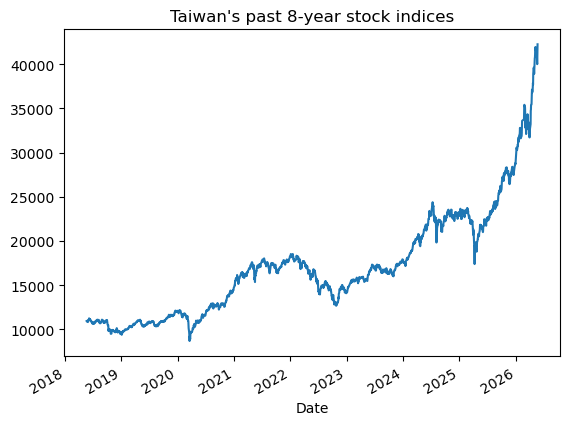

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-18 00:00:00+08:00,41095.820312,41095.820312,40170.171875,40891.820312,6319000,0.0,0.0
2026-05-19 00:00:00+08:00,40883.421875,40951.558594,40168.511719,40175.558594,6548000,0.0,0.0
2026-05-20 00:00:00+08:00,40204.160156,40439.039062,39967.078125,40020.820312,6049500,0.0,0.0
2026-05-21 00:00:00+08:00,40263.179688,41606.910156,40263.179688,41368.210938,6705300,0.0,0.0
2026-05-22 00:00:00+08:00,41447.921875,42357.601562,41447.921875,42267.968750,7704200,0.0,0.0


In [16]:
# ^TWII is the symbol of Taiwan Stock in Yahoo! Finance
tickerData = yf.Ticker('^TWII')
TWII = tickerData.history(period="8y")
TWII['Close'].plot(title="Taiwan's past 8-year stock indices")
plt.show()
TWII.tail()

## 一次讀取多家公司的股市資料  (yf.Tickers)

In [17]:
# To initialize multiple Ticker objects
data_multiple = yf.Tickers('MSFT AAPL GOOG')
data_multiple.tickers['MSFT'].info

{'address1': 'One Microsoft Way',
 'city': 'Redmond',
 'state': 'WA',
 'zip': '98052-6399',
 'country': 'United States',
 'phone': '425 882 8080',
 'website': 'https://www.microsoft.com',
 'industry': 'Software - Infrastructure',
 'industryKey': 'software-infrastructure',
 'industryDisp': 'Software - Infrastructure',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Microsoft Corporation develops and supports software, services, devices, and solutions worldwide. The Productivity and Business Processes segment offers Microsoft 365 commercial, enterprise mobility + security, windows commercial, power BI, exchange, sharepoint, Microsoft teams, security and compliance, and copilot; Microsoft 365 commercial products, such as Windows commercial on-premises and office licensed services; Microsoft 365 consumer products and cloud services, including Microsoft 365 consumer subscriptions, office licensed on-premises, and other consumer serv

In [18]:
data_multiple.tickers['MSFT'].history(period="1mo")

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-04-23 00:00:00-04:00,418.982538,422.744379,410.520854,414.851471,38308000,0.00,0.0
2026-04-24 00:00:00-04:00,416.068840,424.031605,414.901356,423.702301,27457400,0.00,0.0
2026-04-27 00:00:00-04:00,421.467157,426.186915,416.168635,423.901886,30867300,0.00,0.0
2026-04-28 00:00:00-04:00,423.652418,428.990862,420.988175,428.322296,30438100,0.00,0.0
2026-04-29 00:00:00-04:00,423.662369,425.897548,419.381662,423.542633,38288300,0.00,0.0
2026-04-30 00:00:00-04:00,409.922163,413.524377,397.149838,406.898712,70909400,0.00,0.0
2026-05-01 00:00:00-04:00,411.907841,416.208524,409.552956,413.544312,31372400,0.00,0.0
2026-05-04 00:00:00-04:00,410.650583,419.870604,409.912162,412.726074,28066500,0.00,0.0
2026-05-05 00:00:00-04:00,414.422424,415.879260,407.916495,410.490936,25700900,0.00,0.0


## 一次比較及呈現多家公司的股市資料趨勢圖

[*********************100%***********************]  3 of 3 completed


<Axes: title={'center': 'Microsoft/Google/Apple past 1-year stock indices'}, xlabel='Date'>

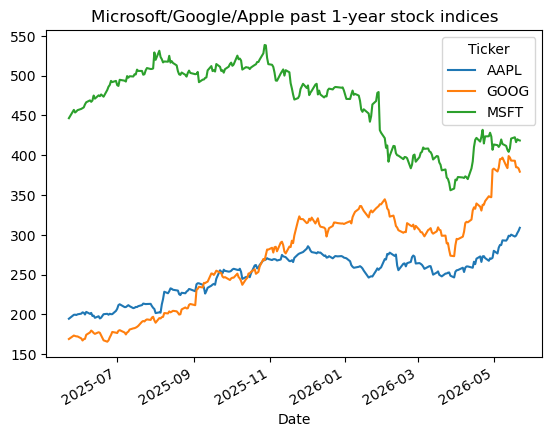

In [19]:
Three_Comp = data_multiple.history(period="1y")
Three_Comp['Close'].plot(title="Microsoft/Google/Apple past 1-year stock indices")

### 讀入股市資料並進行資料清理

### 讀取國際股市漲跌資料及資料清理的詳細資訊請參考第9次實習的內容


In [31]:
# 將股票代碼對應的地區資料讀入
area = pd.read_csv('area.csv')
area

,Area,Code
0,Taiwan,^TWII
1,Australia,^AORD
2,Australia,^AXJO
3,Japan,^N225
4,NewZealand,^NZ50
5,UnitedStates,^DJI
6,UnitedStates,^GSPC
7,Germany,^GDAXI
8,France,^FCHI
9,HongKong,^HSI


In [32]:
# 將股市代號分為:
# 1. 收盤時間同一日，但是比台灣收盤時間稍早的股市代號(earlier_stocks)，例如澳洲、紐西蘭、日本等
# 2. 收盤時間較台灣晚的股市代號(later_stocks), 例如歐洲及美國等國家
#    如果是因為收盤時間比台灣較晚,若要使用這些股市來進行預測,則需使用相對前一日的收盤資料進行當日的預測分析
earlier_taiwan_contries = ['Australia', 'NewZealand', 'Japan']  # 收盤時間同一日但稍早於台灣的國家
taiwan_stock = '^TWII'  # 台灣股市代號(TSEC weighted index)
earlier_stocks = list(
    area[area['Area'].isin(earlier_taiwan_contries)]['Code'])
later_stocks = list(
    area[~area['Area'].isin(earlier_taiwan_contries)]['Code'])
later_stocks.remove(taiwan_stock)

print(f'Taiwan: {taiwan_stock}')
print(f'Closing time on the same day but earlier than Taiwan: {earlier_stocks}')
print(f'Closing time Later than Taiwan: {later_stocks}')

Taiwan: ^TWII
Closing time on the same day but earlier than Taiwan: ['^AORD', '^AXJO', '^N225', '^NZ50']
Closing time Later than Taiwan: ['^DJI', '^GSPC', '^GDAXI', '^FCHI', '^HSI', '^KS11', '^JKSE', '^BSESN', '^BVSP', '^GSPTSE', '^MXX', '^BUK100P', '^STOXX50E', '^TA125.TA', '000001.SS', 'IMOEX.ME', '^BFX']


In [33]:
def read(
    symbol: str,
    period: str = '1y',
    interval: str = '1d',
) -> pd.Series:
    ticker = yf.Ticker(symbol)
    history = ticker.history(period=period, interval=interval)

    # attach timezone information on dates
    # tz = pytz.timezone(ticker.info['exchangeTimezoneName'])
    # history.index = history.index.tz_localize(tz)

    return history['Close'].rename(symbol)

In [36]:
# timezone are attached
# UTC+8
display(read('^TWII'))

# UTC-4
display(read('^DJI'))

Date
2025-05-22 00:00:00+08:00    21670.960938
2025-05-23 00:00:00+08:00    21652.240234
2025-05-26 00:00:00+08:00    21536.570312
2025-05-27 00:00:00+08:00    21336.539062
2025-05-28 00:00:00+08:00    21357.720703
                                 ...     
2026-05-18 00:00:00+08:00    40891.820312
2026-05-19 00:00:00+08:00    40175.558594
2026-05-20 00:00:00+08:00    40020.820312
2026-05-21 00:00:00+08:00    41368.210938
2026-05-22 00:00:00+08:00    42267.968750
Name: ^TWII, Length: 244, dtype: float64

Date
2025-05-23 00:00:00-04:00    41603.070312
2025-05-27 00:00:00-04:00    42343.648438
2025-05-28 00:00:00-04:00    42098.699219
2025-05-29 00:00:00-04:00    42215.730469
2025-05-30 00:00:00-04:00    42270.070312
                                 ...     
2026-05-18 00:00:00-04:00    49686.121094
2026-05-19 00:00:00-04:00    49363.878906
2026-05-20 00:00:00-04:00    50009.351562
2026-05-21 00:00:00-04:00    50285.660156
2026-05-22 00:00:00-04:00    50579.699219
Name: ^DJI, Length: 251, dtype: float64

In [70]:
symbols = [
    '^DJI',
    '^AORD',
    '^TWII',
]

# takes about 5 minutes to download these 24 global indices within a year
results = []
for symbol in symbols:
    result = read(symbol, period='6mo', interval='1d')

    # convert timezone into 'Asia/Taipei'
    result.index = result.index.tz_convert(pytz.timezone('Asia/Taipei'))
    # remain only date information
    result.index = result.index.date
    
    results.append(result)

# column_names=["Date", symbols]   
# print(column_names)

history = pd.concat(results, axis='columns')
history

,^DJI,^AORD,^TWII
2025-11-24,46448.269531,8824.200195,26504.240234
2025-11-25,47112.449219,8899.299805,26912.169922
2025-11-26,47427.121094,8919.799805,27409.539062
2025-11-28,47716.421875,NaN,27626.480469
2025-12-01,47289.328125,8877.500000,27342.529297
...,...,...,...
2026-04-19,NaN,9174.099609,NaN
2026-04-26,NaN,8990.799805,NaN
2026-05-03,NaN,8923.799805,NaN
2026-05-10,NaN,8942.400391,NaN


In [71]:
history

,^DJI,^AORD,^TWII
2025-11-24,46448.269531,8824.200195,26504.240234
2025-11-25,47112.449219,8899.299805,26912.169922
2025-11-26,47427.121094,8919.799805,27409.539062
2025-11-28,47716.421875,NaN,27626.480469
2025-12-01,47289.328125,8877.500000,27342.529297
...,...,...,...
2026-04-19,NaN,9174.099609,NaN
2026-04-26,NaN,8990.799805,NaN
2026-05-03,NaN,8923.799805,NaN
2026-05-10,NaN,8942.400391,NaN


In [72]:
# 使用 Pickle 模組保存資料，壓縮資料、保存、並隨時隨地解開儲存好的資料，還原工作階段
history.to_pickle('history.pkl.zip')

In [73]:
history = pd.read_pickle('history.pkl.zip')

In [74]:
history.head()

,^DJI,^AORD,^TWII
2025-11-24,46448.269531,8824.200195,26504.240234
2025-11-25,47112.449219,8899.299805,26912.169922
2025-11-26,47427.121094,8919.799805,27409.539062
2025-11-28,47716.421875,NaN,27626.480469
2025-12-01,47289.328125,8877.500000,27342.529297


In [75]:
# shift target stock negatively for reasonable prediction
history['^TWII'] = history['^TWII'].shift(-1)

history.dropna(inplace=True)
history

,^DJI,^AORD,^TWII
2025-11-24,46448.269531,8824.200195,26912.169922
2025-11-25,47112.449219,8899.299805,27409.539062
2025-11-26,47427.121094,8919.799805,27626.480469
2025-12-01,47289.328125,8877.500000,27564.269531
2025-12-02,47474.460938,8894.200195,27793.039062
...,...,...,...
2026-05-14,50063.460938,8870.599609,41172.359375
2026-05-18,49686.121094,8829.500000,40175.558594
2026-05-19,49363.878906,8717.000000,40020.820312
2026-05-20,50009.351562,8840.799805,41368.210938


In [76]:
# 去除有空值的紀錄
history.dropna(inplace=True)
# 將收盤價的欄位轉為數值
history.iloc[:, 1:] = history.iloc[:, 1:].apply(pd.to_numeric)
history.head(10)

,^DJI,^AORD,^TWII
2025-11-24,46448.269531,8824.200195,26912.169922
2025-11-25,47112.449219,8899.299805,27409.539062
2025-11-26,47427.121094,8919.799805,27626.480469
2025-12-01,47289.328125,8877.500000,27564.269531
2025-12-02,47474.460938,8894.200195,27793.039062
2025-12-03,47882.898438,8906.700195,27795.710938
2025-12-04,47850.941406,8926.099609,27980.890625
2025-12-08,47739.320312,8875.799805,28182.599609
2025-12-09,47560.289062,8868.200195,28400.730469
2025-12-10,48057.750000,8877.500000,28024.750000


## 前一天股價比較並記錄漲跌

透過與前一天收盤價相比，計算當天收盤價為上漲 (True) 或是下跌 (False)


In [77]:
updowns = history > history.shift(-1)
updowns

,^DJI,^AORD,^TWII
2025-11-24,False,False,False
2025-11-25,False,False,False
2025-11-26,True,True,True
2025-12-01,False,False,False
2025-12-02,False,False,False
...,...,...,...
2026-05-14,True,True,True
2026-05-18,True,True,True
2026-05-19,False,False,False
2026-05-20,False,False,False


## 使用 Naive Bayes 進行資料分類，並繪製 confusion matrix

### 透過 scikit-learn 計算 Naive Bayes 分類結果，並以 seaborn 中 heatmap 呈現


In [78]:
train, test = train_test_split(updowns, test_size=0.2, random_state=100)

In [81]:
target = '^TWII'
X_train = train.drop(columns=target)
y_train = train[target]
X_test = test.drop(columns=target)
y_test = test[target]

In [82]:
y_train.count()

np.int64(71)

In [83]:
X_train.count()

^DJI     71
^AORD    71
dtype: int64

In [84]:
# Naive Bayes classifier for multivariate Bernoulli models
model_B = BernoulliNB().fit(X_train, y_train)
model_B.score(X_test, y_test)

0.6111111111111112

## 計算 confusion matrix

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

In [87]:
pred = model_B.predict(X_test)
matrix = confusion_matrix(y_test, pred)
matrix

array([[6, 1],
       [6, 5]])

<Axes: >

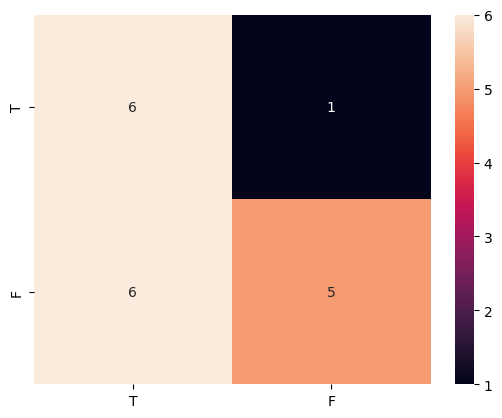

In [88]:
sn.heatmap(matrix, annot=True, xticklabels=['T', 'F'], yticklabels=['T', 'F'])

### 高斯貝氏分類器 GaussianNB
### 高斯分類器主要用於特徵為連續變數時，例如鳶尾花的花瓣、花萼特徵長度及寬度為幾公分、重量為幾公斤等等。在這個模型下，假設特徵資料服從常態分配。

In [89]:
from sklearn import datasets

In [90]:
iris=datasets.load_iris()
X=iris.data
y=iris.target

In [91]:
# 將資料拆分成訓練集與測試集 7:3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [92]:
# 模型建立與分析 (使用高斯貝氏分類器 Gaussian Naive Bayes)
model_G = GaussianNB().fit(X_train, y_train)
model_G.score(X_test, y_test)

1.0

In [93]:
model_G.predict(X_test)

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0, 2, 1, 0, 2, 2, 1, 0, 1, 1, 1, 2, 0, 2, 0,
       0])

In [94]:
# 可以透過predict_proba()來看每個樣本在各個類別下發生的機率。
model_G.predict_proba(X_test)

array([[2.44049291e-261, 1.75690913e-006, 9.99998243e-001],
       [4.62772960e-087, 9.99997509e-001, 2.49062165e-006],
       [1.00000000e+000, 5.86573779e-018, 8.16162532e-027],
       [2.96439388e-323, 1.10744521e-006, 9.99998893e-001],
       [1.00000000e+000, 3.17267813e-016, 5.32610050e-026],
       [0.00000000e+000, 1.46019193e-010, 1.00000000e+000],
       [1.00000000e+000, 4.31839423e-016, 7.65911289e-026],
       [8.09217628e-158, 7.80399392e-001, 2.19600608e-001],
       [7.24579939e-160, 9.08267456e-001, 9.17325438e-002],
       [8.90967866e-101, 9.99849842e-001, 1.50157614e-004],
       [1.04517663e-220, 4.70717779e-001, 5.29282221e-001],
       [8.85444946e-143, 9.41915811e-001, 5.80841887e-002],
       [3.77596535e-139, 9.98630652e-001, 1.36934795e-003],
       [1.30323456e-150, 9.46178914e-001, 5.38210855e-002],
       [1.08449063e-149, 9.85985808e-001, 1.40141923e-002],
       [1.00000000e+000, 3.83418804e-018, 7.85663405e-028],
       [7.01016623e-142, 9.85419351e-001

### 伯努力貝氏分類器主要適用於二元的特徵，比方說特徵是否出現、特徵大小、特徵長短等等這種二元的分類。
## 若使用錯誤，預測效果就非常不佳。

In [95]:
# 例如錯誤模型建立與分析 (使用伯努力貝氏分類器 Bernoulli Naive Bayes)
# 將資料拆分成訓練集與測試集 7:3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
model_B = BernoulliNB().fit(X_train, y_train)
model_B.score(X_test, y_test)

0.28888888888888886

In [96]:
model_B.predict(X_test)

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2])

In [97]:
# 可以透過predict_proba()來看每個樣本在各個類別下發生的機率。
model_B.predict_proba(X_test)

array([[0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.34384738, 0.30177328, 0.35437934],
       [0.

### 多項式貝氏分類器 MultinomialNB
多項式貝氏分類器主要用在離散變數，比方說次數、類別等等。而在個模型中，會多一個參數，也就是平滑化的處理。

In [98]:
# 模型建立與分析 (使用多項式貝氏分類器 Multinomial Naive Bayes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)
model_M = MultinomialNB().fit(X_train, y_train)
model_M.score(X_test, y_test)

0.9111111111111111

In [99]:
model_M.predict(X_test)

array([0, 0, 2, 0, 0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 1, 1, 0, 1, 2, 1, 2, 1,
       2, 1, 1, 0, 0, 2, 0, 2, 2, 0, 1, 2, 2, 0, 2, 1, 2, 2, 2, 1, 2, 1,
       0])

In [100]:
# 可以透過predict_proba()來看每個樣本在各個類別下發生的機率。
model_M.predict_proba(X_test)

array([[0.67583928, 0.20167572, 0.122485  ],
       [0.64830476, 0.21739671, 0.13429853],
       [0.00871369, 0.43639946, 0.55488685],
       [0.6906429 , 0.1940111 , 0.115346  ],
       [0.62803437, 0.231269  , 0.14069663],
       [0.01507903, 0.48435685, 0.50056411],
       [0.6348813 , 0.22678157, 0.13833713],
       [0.00759853, 0.45210532, 0.54029615],
       [0.00662621, 0.44070242, 0.55267137],
       [0.63009249, 0.22767337, 0.14223414],
       [0.7523428 , 0.16016276, 0.08749444],
       [0.68713212, 0.19428119, 0.11858669],
       [0.72755734, 0.17279987, 0.09964279],
       [0.69586704, 0.19414795, 0.10998501],
       [0.04050419, 0.4858518 , 0.47364401],
       [0.03319722, 0.48714019, 0.4796626 ],
       [0.53146029, 0.27793112, 0.1906086 ],
       [0.05280615, 0.48441374, 0.46278011],
       [0.00510739, 0.43451783, 0.56037478],
       [0.04658522, 0.47724277, 0.47617201],
       [0.02197035, 0.48171808, 0.49631157],
       [0.05622457, 0.49395417, 0.44982126],
       [0.